#Kernal SVM - Non Linear
kernel='rbf'

#Author- Yashas Samaga

###imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



### Datasets

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')
print(df)
print(df.shape)

     Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[400 rows x 3 columns]
(400, 3)


In [3]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

print("Features")
print(x)

print("Dependent Variable")
print(y)

Features
[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    28  79000]
 [   

### splitting data

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25,random_state=0)
print(x_test)
print(y_test)

[[    30  87000]
 [    38  50000]
 [    35  75000]
 [    30  79000]
 [    35  50000]
 [    27  20000]
 [    31  15000]
 [    36 144000]
 [    18  68000]
 [    47  43000]
 [    30  49000]
 [    28  55000]
 [    37  55000]
 [    39  77000]
 [    20  86000]
 [    32 117000]
 [    37  77000]
 [    19  85000]
 [    55 130000]
 [    35  22000]
 [    35  47000]
 [    47 144000]
 [    41  51000]
 [    47 105000]
 [    23  28000]
 [    49 141000]
 [    28  87000]
 [    29  80000]
 [    37  62000]
 [    32  86000]
 [    21  88000]
 [    37  79000]
 [    57  60000]
 [    37  53000]
 [    24  58000]
 [    18  52000]
 [    22  81000]
 [    34  43000]
 [    31  34000]
 [    49  36000]
 [    27  88000]
 [    41  52000]
 [    27  84000]
 [    35  20000]
 [    43 112000]
 [    27  58000]
 [    37  80000]
 [    52  90000]
 [    26  30000]
 [    49  86000]
 [    57 122000]
 [    34  25000]
 [    35  57000]
 [    34 115000]
 [    59  88000]
 [    45  32000]
 [    29  83000]
 [    26  80000]
 [    49  2800

### Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print(x_train_scaled)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

### Training Kernal SVM - Non Linear  model

In [6]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf')
classifier.fit(x_train_scaled,y_train)

SVC()

### Predicting a new Result

In [7]:
print(classifier.predict(scaler.transform([[30,87000]])))

[0]


### Predicting Test set results

In [8]:
y_predicted=classifier.predict(x_test_scaled)
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1])

In [9]:
import numpy as np
np.concatenate( ( y_test.reshape(-1,1 ) ,y_predicted.reshape(-1,1) ), axis=1)

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0,

### Confusion metrix and Accuracy

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
print(cm)

[[64  4]
 [ 3 29]]


In [11]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_predicted)

0.93

In [12]:
print("Age range:", x_train[:,0].min(), x_train[:,0].max())
print("Salary range:", x_train[:,1].min(), x_train[:,1].max())
print("Expected grid points:",
      len(np.arange(x_train[:,0].min()-10, x_train[:,0].max()+10, 0.25))
      *
      len(np.arange(x_train[:,1].min()-1000, x_train[:,1].max()+1000, 0.25)))

Age range: 18 60
Salary range: 15000 150000
Expected grid points: 135904000


### Visualising the Training set results

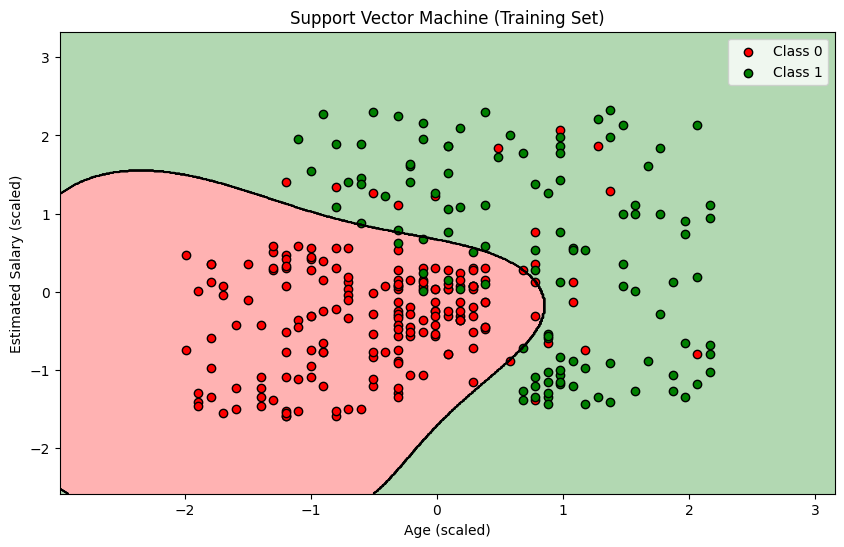

In [13]:
from matplotlib.colors import ListedColormap
scaler_y = StandardScaler()

X_set, y_set = x_train_scaled, y_train
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1,
              X_set[:, 0].max() + 1,
              0.01),
    np.arange(X_set[:, 1].min() - 1,
              X_set[:, 1].max() + 1,
              0.01)
)

Z = classifier.predict(
    np.c_[X1.ravel(), X2.ravel()]
).reshape(X1.shape)

plt.figure(figsize=(10, 6))

plt.contourf(
    X1, X2, Z,
    alpha=0.3,
    cmap=ListedColormap(("red", "green"))
)

plt.contour(
    X1, X2, Z,
    colors="black",
    linewidths=1
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=["red", "green"][i],
        label=f"Class {j}",
        edgecolors="black"
    )

plt.title("Support Vector Machine (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()

### Visualising the Test set results

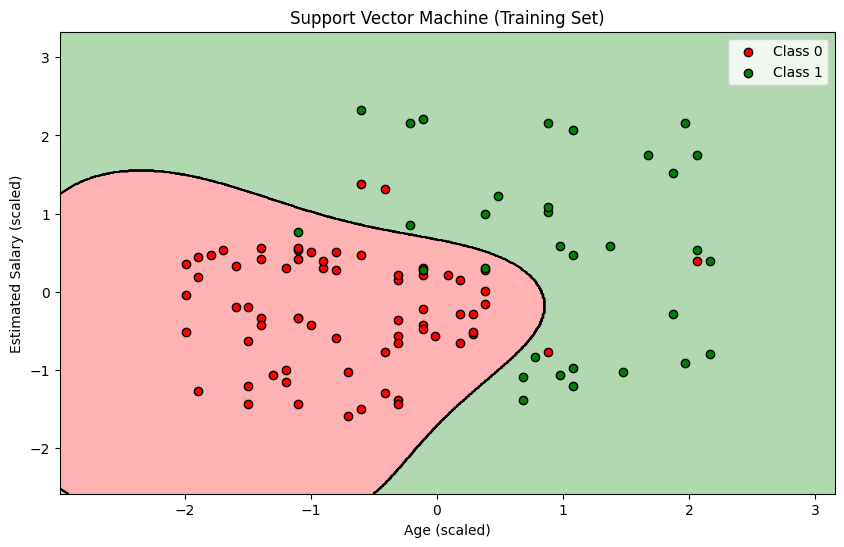

In [14]:
from matplotlib.colors import ListedColormap
scaler_y = StandardScaler()

X_set, y_set = x_test_scaled, y_test
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1,
              X_set[:, 0].max() + 1,
              0.01),
    np.arange(X_set[:, 1].min() - 1,
              X_set[:, 1].max() + 1,
              0.01)
)

Z = classifier.predict(
    np.c_[X1.ravel(), X2.ravel()]
).reshape(X1.shape)

plt.figure(figsize=(10, 6))

plt.contourf(
    X1, X2, Z,
    alpha=0.3,
    cmap=ListedColormap(("red", "green"))
)

plt.contour(
    X1, X2, Z,
    colors="black",
    linewidths=1
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=["red", "green"][i],
        label=f"Class {j}",
        edgecolors="black"
    )

plt.title("Support Vector Machine (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()